# 🏷️ LLM Fine-tuning for Text Classification
Fine-tuning GPT-2 (124M) on the SMS Spam Collection dataset to build a binary spam classifier.

**Pipeline overview:**
1. Setup – model architecture + GPT-2 pretrained weights  
2. Dataset download & preparation  
3. SpamDataset & DataLoaders  
4. Add classification head  
5. Train & evaluate  
6. Inference & save model  


## Section 1 — Setup: Install dependencies & define model architecture

In [23]:
# Install required packages (uncomment if running for the first time)
# !pip install torch tiktoken tensorflow tqdm numpy pandas matplotlib

import torch
import torch.nn as nn
import numpy as np
import tiktoken


### 1.1 GPT-2 Model Architecture

In [24]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), "d_out must be divisible by num_heads"
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        q = self.W_query(x).view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.W_key(x).view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.W_value(x).view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        attn = (q @ k.transpose(-2, -1)) / (self.head_dim ** 0.5)
        attn = attn.masked_fill(self.mask[:num_tokens, :num_tokens].bool(), float("-inf"))
        attn = torch.softmax(attn, dim=-1)
        attn = self.dropout(attn)
        out = (attn @ v).transpose(1, 2).contiguous().view(b, num_tokens, self.d_out)
        return self.out_proj(out)


class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var  = x.var(dim=-1, keepdim=True, unbiased=False)
        return self.scale * (x - mean) / torch.sqrt(var + self.eps) + self.shift


class GELU(nn.Module):
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * x**3)))


class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )
    def forward(self, x):
        return self.layers(x)


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"], d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff   = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        x = x + self.drop_shortcut(self.att(self.norm1(x)))
        x = x + self.drop_shortcut(self.ff(self.norm2(x)))
        return x


class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb  = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb  = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head   = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        b, seq_len = in_idx.shape
        x = self.tok_emb(in_idx) + self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        return self.out_head(x)


### 1.2 Utility functions (text generation & tokenization)

In [25]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]
        idx_next = torch.argmax(logits, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1)
    return idx

tokenizer = tiktoken.get_encoding("gpt2")

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    return torch.tensor(encoded).unsqueeze(0)

def token_ids_to_text(token_ids, tokenizer):
    return tokenizer.decode(token_ids.squeeze(0).tolist())


### 1.3 Load GPT-2 pretrained weights

In [26]:
# Download the gpt_download3.py helper if not already present
import os, urllib.request, ssl

helper_url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch05/01_main-chapter-code/gpt_download.py"
)
if not os.path.exists("gpt_download3.py"):
    ssl_ctx = ssl.create_default_context()
    ssl_ctx.check_hostname = False
    ssl_ctx.verify_mode = ssl.CERT_NONE
    with urllib.request.urlopen(helper_url, context=ssl_ctx) as r:
        with open("gpt_download3.py", "wb") as f:
            f.write(r.read())
    print("Downloaded gpt_download3.py")


In [27]:
from gpt_download3 import download_and_load_gpt2

CHOOSE_MODEL = "gpt2-small (124M)"   # change to 355M / 774M / 1558M if desired

BASE_CONFIG = {
    "vocab_size": 50257,
    "context_length": 1024,
    "drop_rate": 0.0,
    "qkv_bias": True
}
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768,  "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)":{"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)":   {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")


File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


In [28]:
def assign(original_weight, new_weight):
    original_weight.data = torch.tensor(new_weight)
    return original_weight

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params["wpe"])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params["wte"])
    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(params["blocks"][b]["attn"]["c_attn"]["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight   = assign(gpt.trf_blocks[b].att.W_key.weight,   k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(gpt.trf_blocks[b].att.W_value.weight, v_w.T)
        q_b, k_b, v_b = np.split(params["blocks"][b]["attn"]["c_attn"]["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias   = assign(gpt.trf_blocks[b].att.W_key.bias,   k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(gpt.trf_blocks[b].att.W_value.bias, v_b)
        gpt.trf_blocks[b].att.out_proj.weight = assign(gpt.trf_blocks[b].att.out_proj.weight, params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias   = assign(gpt.trf_blocks[b].att.out_proj.bias,   params["blocks"][b]["attn"]["c_proj"]["b"])
        gpt.trf_blocks[b].ff.layers[0].weight = assign(gpt.trf_blocks[b].ff.layers[0].weight, params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias   = assign(gpt.trf_blocks[b].ff.layers[0].bias,   params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(gpt.trf_blocks[b].ff.layers[2].weight, params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias   = assign(gpt.trf_blocks[b].ff.layers[2].bias,   params["blocks"][b]["mlp"]["c_proj"]["b"])
        gpt.trf_blocks[b].norm1.scale = assign(gpt.trf_blocks[b].norm1.scale, params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(gpt.trf_blocks[b].norm1.shift, params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(gpt.trf_blocks[b].norm2.scale, params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(gpt.trf_blocks[b].norm2.shift, params["blocks"][b]["ln_2"]["b"])
    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight  = assign(gpt.out_head.weight,  params["wte"])

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Model loaded on: {device}")


Model loaded on: cuda


In [29]:
# Quick sanity check – verify coherent text generation
test_text = "Every effort moves you"
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(test_text, tokenizer).to(device),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))


Every effort moves you forward.

The first step is to understand the importance of your work


## Section 2 — Dataset: SMS Spam Collection
Download, balance (equal ham/spam), and split into train/val/test sets.


In [30]:
import urllib.request, ssl, zipfile, os, pandas as pd
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"Dataset already exists at {data_file_path}")
        return
    ssl_ctx = ssl.create_default_context()
    ssl_ctx.check_hostname = False
    ssl_ctx.verify_mode = ssl.CERT_NONE
    with urllib.request.urlopen(url, context=ssl_ctx) as r:
        with open(zip_path, "wb") as f:
            f.write(r.read())
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extracted_path)
    original = Path(extracted_path) / "SMSSpamCollection"
    original.rename(data_file_path)
    print(f"Downloaded and saved to {data_file_path}")

download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

df = pd.read_csv(data_file_path, sep="\t", header=None, names=["Label", "Text"])
print(df["Label"].value_counts())
df.head()


Dataset already exists at sms_spam_collection/SMSSpamCollection.tsv
Label
ham     4825
spam     747
Name: count, dtype: int64


,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [31]:
def create_balanced_dataset(df):
    num_spam = df[df["Label"] == "spam"].shape[0]
    ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=123)
    return pd.concat([ham_subset, df[df["Label"] == "spam"]])

balanced_df = create_balanced_dataset(df)
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})
print(balanced_df["Label"].value_counts())

def random_split(df, train_frac, validation_frac):
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)
    train_end = int(len(df) * train_frac)
    val_end   = train_end + int(len(df) * validation_frac)
    return df[:train_end], df[train_end:val_end], df[val_end:]

train_df, val_df, test_df = random_split(balanced_df, 0.70, 0.10)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

train_df.to_csv("train.csv", index=False)
val_df.to_csv("validation.csv", index=False)
test_df.to_csv("test.csv", index=False)


Label
0    747
1    747
Name: count, dtype: int64
Train: 1045 | Val: 149 | Test: 300


## Section 3 — SpamDataset & DataLoaders
Pad/truncate sequences to uniform length, then create PyTorch DataLoaders.


In [32]:
from torch.utils.data import Dataset, DataLoader

class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(csv_file)
        self.encoded_texts = [tokenizer.encode(t) for t in self.data["Text"]]
        if max_length is None:
            self.max_length = max(len(e) for e in self.encoded_texts)
        else:
            self.max_length = max_length
        # Truncate
        self.encoded_texts = [e[:self.max_length] for e in self.encoded_texts]
        # Pad
        self.encoded_texts = [
            e + [pad_token_id] * (self.max_length - len(e))
            for e in self.encoded_texts
        ]

    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label   = self.data.iloc[index]["Label"]
        return torch.tensor(encoded, dtype=torch.long), torch.tensor(label, dtype=torch.long)

    def __len__(self):
        return len(self.data)

train_dataset = SpamDataset("train.csv",      tokenizer=tokenizer)
val_dataset   = SpamDataset("validation.csv", tokenizer=tokenizer, max_length=train_dataset.max_length)
test_dataset  = SpamDataset("test.csv",       tokenizer=tokenizer, max_length=train_dataset.max_length)
print(f"Max sequence length: {train_dataset.max_length} tokens")


Max sequence length: 120 tokens


In [33]:
batch_size = 8
torch.manual_seed(123)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  drop_last=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, drop_last=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, drop_last=False, num_workers=0)

print(f"{len(train_loader)} train batches | {len(val_loader)} val batches | {len(test_loader)} test batches")


130 train batches | 19 val batches | 38 test batches


## Section 4 — Classification Head
Replace the 50,257-dim language-model head with a 2-dim classifier head.  
Freeze all layers except the new head and the last transformer block.


In [34]:
# Freeze all parameters
for param in model.parameters():
    param.requires_grad = False

# Replace output head: 768 → 2 classes (ham=0, spam=1)
num_classes = 2
model.out_head = nn.Linear(in_features=BASE_CONFIG["emb_dim"], out_features=num_classes)

# Unfreeze last transformer block + final layer norm
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True
for param in model.final_norm.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")


Trainable params: 7,090,946 / 124,441,346


## Section 5 — Train & Evaluate

In [35]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)[:, -1, :]          # last token output
    return torch.nn.functional.cross_entropy(logits, target_batch)

def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    n = len(data_loader) if num_batches is None else min(num_batches, len(data_loader))
    for i, (xb, yb) in enumerate(data_loader):
        if i >= n: break
        total_loss += calc_loss_batch(xb, yb, model, device).item()
    return total_loss / n

def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct, total = 0, 0
    n = len(data_loader) if num_batches is None else min(num_batches, len(data_loader))
    for i, (xb, yb) in enumerate(data_loader):
        if i >= n: break
        xb, yb = xb.to(device), yb.to(device)
        with torch.no_grad():
            logits = model(xb)[:, -1, :]
        preds = torch.argmax(logits, dim=-1)
        correct += (preds == yb).sum().item()
        total   += yb.size(0)
    return correct / total

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        tl = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        vl = calc_loss_loader(val_loader,   model, device, num_batches=eval_iter)
    model.train()
    return tl, vl


In [36]:
def train_classifier_simple(model, train_loader, val_loader, optimizer, device,
                             num_epochs, eval_freq, eval_iter):
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(xb, yb, model, device)
            loss.backward()
            optimizer.step()
            examples_seen += xb.size(0)
            global_step   += 1
            if global_step % eval_freq == 0:
                tl, vl = evaluate_model(model, train_loader, val_loader, device, eval_iter)
                train_losses.append(tl); val_losses.append(vl)
                print(f"Ep {epoch+1} (Step {global_step:06d}): Train loss {tl:.3f}, Val loss {vl:.3f}")

        ta = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        va = calc_accuracy_loader(val_loader,   model, device, num_batches=eval_iter)
        print(f"  → Train acc: {ta*100:.2f}% | Val acc: {va*100:.2f}%")
        train_accs.append(ta); val_accs.append(va)

    return train_losses, val_losses, train_accs, val_accs, examples_seen


In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=model.to(device)
import time, matplotlib.pyplot as plt

torch.manual_seed(123)
optimizer  = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5

start = time.time()
train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=50, eval_iter=5
)
print(f"\nTraining time: {(time.time()-start)/60:.2f} min")


Ep 1 (Step 000000): Train loss 2.153, Val loss 2.392
Ep 1 (Step 000050): Train loss 0.617, Val loss 0.637
Ep 1 (Step 000100): Train loss 0.523, Val loss 0.557
  → Train acc: 70.00% | Val acc: 72.50%
Ep 2 (Step 000150): Train loss 0.561, Val loss 0.489
Ep 2 (Step 000200): Train loss 0.419, Val loss 0.397
Ep 2 (Step 000250): Train loss 0.409, Val loss 0.353
  → Train acc: 82.50% | Val acc: 85.00%
Ep 3 (Step 000300): Train loss 0.333, Val loss 0.320
Ep 3 (Step 000350): Train loss 0.340, Val loss 0.306
  → Train acc: 90.00% | Val acc: 90.00%
Ep 4 (Step 000400): Train loss 0.136, Val loss 0.200
Ep 4 (Step 000450): Train loss 0.153, Val loss 0.132
Ep 4 (Step 000500): Train loss 0.222, Val loss 0.137
  → Train acc: 100.00% | Val acc: 97.50%
Ep 5 (Step 000550): Train loss 0.207, Val loss 0.143
Ep 5 (Step 000600): Train loss 0.083, Val loss 0.074
  → Train acc: 100.00% | Val acc: 97.50%

Training time: 1.14 min


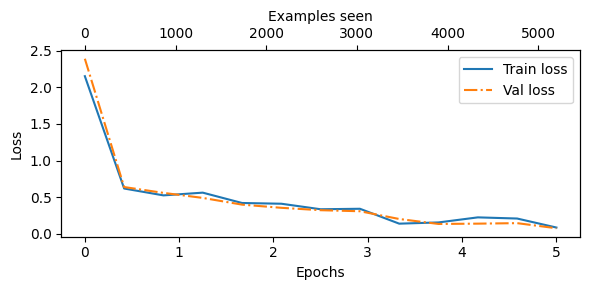

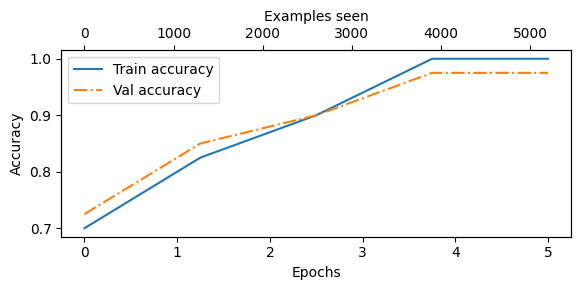

In [38]:
def plot_values(epochs_seen, examples_seen, train_vals, val_vals, label="loss"):
    fig, ax1 = plt.subplots(figsize=(6, 3))
    ax1.plot(epochs_seen, train_vals, label=f"Train {label}")
    ax1.plot(epochs_seen, val_vals,   linestyle="-.", label=f"Val {label}")
    ax1.set_xlabel("Epochs"); ax1.set_ylabel(label.capitalize())
    ax1.legend()
    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_vals, alpha=0)
    ax2.set_xlabel("Examples seen")
    fig.tight_layout(); plt.show()

epochs_t   = torch.linspace(0, num_epochs, len(train_losses))
examples_t = torch.linspace(0, examples_seen, len(train_losses))
plot_values(epochs_t, examples_t, train_losses, val_losses, label="loss")

epochs_t   = torch.linspace(0, num_epochs, len(train_accs))
examples_t = torch.linspace(0, examples_seen, len(train_accs))
plot_values(epochs_t, examples_t, train_accs, val_accs, label="accuracy")


In [39]:
# Final accuracy on full train / val / test sets
train_acc = calc_accuracy_loader(train_loader, model, device)
val_acc   = calc_accuracy_loader(val_loader,   model, device)
test_acc  = calc_accuracy_loader(test_loader,  model, device)
print(f"Train accuracy : {train_acc*100:.2f}%")
print(f"Val   accuracy : {val_acc*100:.2f}%")
print(f"Test  accuracy : {test_acc*100:.2f}%")


Train accuracy : 97.21%
Val   accuracy : 97.32%
Test  accuracy : 95.67%


## Section 6 — Inference & Save Model

In [40]:
def classify_review(text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    model.eval()
    input_ids = tokenizer.encode(text)
    max_ctx   = model.pos_emb.weight.shape[0]
    input_ids = input_ids[:min(max_length or max_ctx, max_ctx)]
    if max_length:
        input_ids += [pad_token_id] * (max_length - len(input_ids))
    tensor = torch.tensor(input_ids, device=device).unsqueeze(0)
    with torch.no_grad():
        logits = model(tensor)[:, -1, :]
    label = torch.argmax(logits, dim=-1).item()
    return "spam" if label == 1 else "not spam"

# Test examples
spam_msg = "You are a winner! You have been specially selected to receive $1000 cash."
ham_msg  = "Hey, just wanted to check if we're still on for dinner tonight? Let me know!"

print(f"Spam test : '{spam_msg[:60]}...' → {classify_review(spam_msg, model, tokenizer, device, train_dataset.max_length)}")
print(f"Ham  test : '{ham_msg[:60]}...' → {classify_review(ham_msg,  model, tokenizer, device, train_dataset.max_length)}")


Spam test : 'You are a winner! You have been specially selected to receiv...' → not spam
Ham  test : 'Hey, just wanted to check if we're still on for dinner tonig...' → not spam


In [41]:
# Save model weights
torch.save(model.state_dict(), "spam_classifier.pth")
print("Model saved to spam_classifier.pth")

# To reload:
# model.load_state_dict(torch.load("spam_classifier.pth", map_location=device))


Model saved to spam_classifier.pth
